In [1]:
import os
from PIL import Image
import torch
from torchvision import models, transforms
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from tqdm import tqdm

In [5]:
print(os.getcwd())

c:\CV\uts


c:\Users\Deniel\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Deniel\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Extracting features: 100%|██████████| 4262/4262 [01:35<00:00, 44.76it/s]
c:\Users\Deniel\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this 

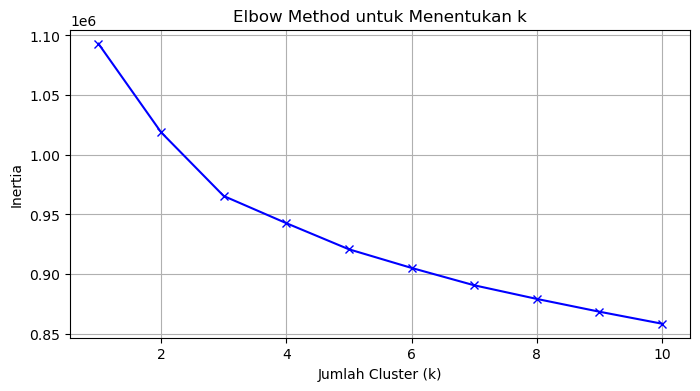

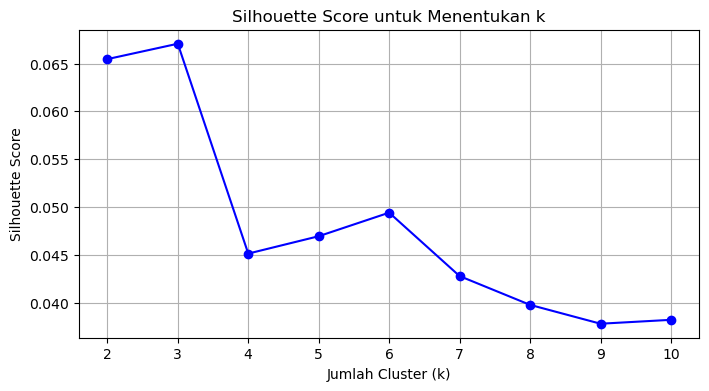

In [2]:
image_folder = "sports_ball_images_full"

# Ambil semua file gambar
image_paths = [os.path.join(image_folder, fname) 
               for fname in os.listdir(image_folder) 
               if fname.lower().endswith((".jpg", ".jpeg", ".png"))]

# Optional: batasi jumlah gambar untuk testing
# image_paths = image_paths[:100]

# === Load pre-trained ResNet50 dan hilangkan FC layer ===
model = models.resnet50(pretrained=True)
model = torch.nn.Sequential(*list(model.children())[:-1])  # buang classifier
model.eval()

# === Image transform ===
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# === Ekstrak fitur dari gambar ===
features = []

for path in tqdm(image_paths, desc="Extracting features"):
    try:
        img = Image.open(path).convert("RGB")
        x = transform(img).unsqueeze(0)  # batch size 1
        with torch.no_grad():
            feat = model(x).squeeze().numpy()
        features.append(feat)
    except Exception as e:
        print(f"Error loading {path}: {e}")

features = np.array(features)

# === Elbow Method ===
inertias = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(features)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K, inertias, 'bx-')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method untuk Menentukan k')
plt.grid(True)
plt.show()

# === Silhouette Score ===
silhouette_scores = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(features)
    score = silhouette_score(features, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 4))
plt.plot(K, silhouette_scores, 'bo-')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score untuk Menentukan k')
plt.grid(True)
plt.show()

In [4]:
import os
import cv2  # OpenCV
import numpy as np

# Ubah ke path folder gambar kamu
folder_path = 'sports_ball_images_full'
image_data = []

for filename in os.listdir(folder_path):
    if filename.endswith(".jpg") or filename.endswith(".png"):
        img_path = os.path.join(folder_path, filename)
        img = cv2.imread(img_path)
        img = cv2.resize(img, (64, 64))  # Resize ke ukuran yang konsisten
        img = img.flatten()  # Ubah jadi 1D array
        image_data.append(img)

image_data = np.array(image_data)  # Sekarang ini bisa dipakai untuk KMeans

In [5]:
best_score = -1
best_state = None
k = 3  # atau jumlah cluster terbaik dari Elbow/Silhouette sebelumnya

for state in range(0, 100):  # coba 100 kemungkinan random state
    kmeans = KMeans(n_clusters=k, random_state=state)
    labels = kmeans.fit_predict(image_data)

    score = silhouette_score(image_data, labels)
    
    if score > best_score:
        best_score = score
        best_state = state

print(f"Random state terbaik: {best_state} dengan silhouette score: {best_score:.4f}")

Random state terbaik: 81 dengan silhouette score: 0.1006


In [7]:
kmeans = KMeans(n_clusters= 3, random_state=81)
labels = kmeans.fit_predict(image_data)  


In [8]:
import pandas as pd

df = pd.DataFrame({
    'image_path': image_paths,
    'cluster': labels
})
df.to_csv("hasil_clustering_sportsball.csv", index=False)

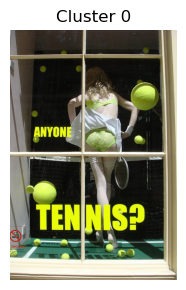

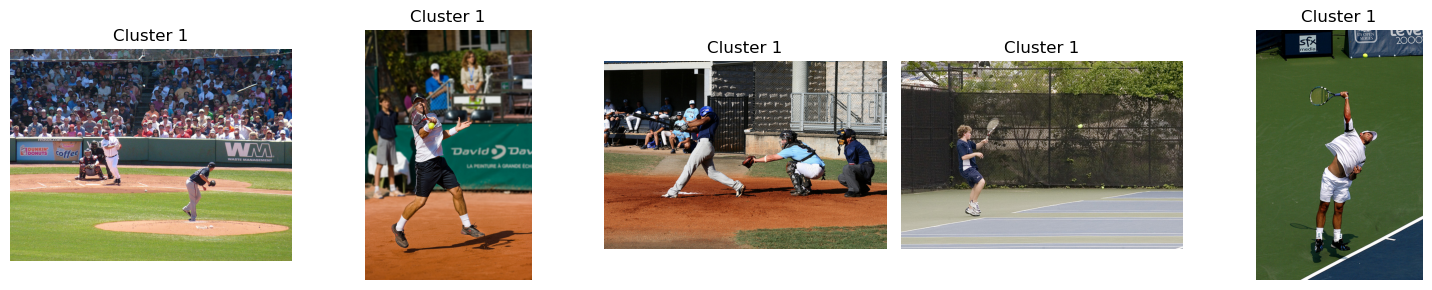

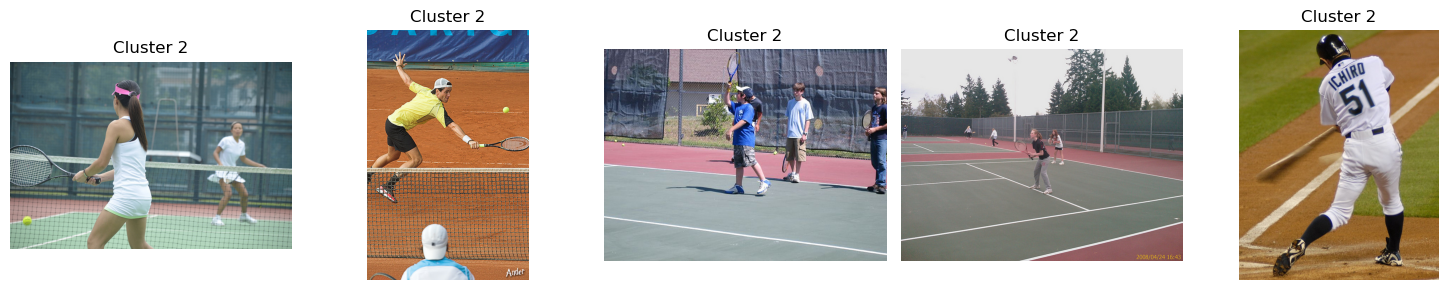

In [9]:
import random

def show_cluster_examples(cluster_id, n=5):
    sample_paths = [p for p, c in zip(image_paths, labels) if c == cluster_id]
    sample_paths = random.sample(sample_paths, min(n, len(sample_paths)))

    plt.figure(figsize=(15, 3))
    for i, path in enumerate(sample_paths):
        img = Image.open(path).convert("RGB")
        plt.subplot(1, n, i + 1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Cluster {cluster_id}")
    plt.tight_layout()
    plt.show()

# Tampilkan contoh dari tiap cluster
for cid in range(3):
    show_cluster_examples(cid)

In [10]:
import shutil
from pathlib import Path

output_base = Path("cluster_output")
output_base.mkdir(exist_ok=True)

for path, label in zip(image_paths, labels):
    cluster_dir = output_base / f"cluster_{label}"
    cluster_dir.mkdir(exist_ok=True)
    shutil.copy(path, cluster_dir / Path(path).name)


In [11]:
from collections import defaultdict

cluster_samples = defaultdict(list)

# Kumpulkan path berdasarkan label cluster
for path, label in zip(image_paths, labels):
    cluster_samples[label].append(path)

# Acak isi cluster
for label in cluster_samples:
    random.shuffle(cluster_samples[label])

# Gabungkan dan ambil maksimal 50 total gambar
combined = []
for label in cluster_samples:
    combined.extend([(p, label) for p in cluster_samples[label]])

# Acak gabungan dan ambil maksimal 50
random.shuffle(combined)
sampled = combined[:50]

# Pisahkan kembali path dan label jika dibutuhkan
sampled_paths = [p for p, _ in sampled]
sampled_labels = [l for _, l in sampled]

print(f"Total sample terpilih: {len(sampled_paths)}")

Total sample terpilih: 50


In [12]:
import shutil
from pathlib import Path

output_dir = Path("final_sampled_50")
output_dir.mkdir(exist_ok=True)

for i, (path, label) in enumerate(sampled):
    fname = f"{label}_{i}_{Path(path).name}"
    shutil.copy(path, output_dir / fname)


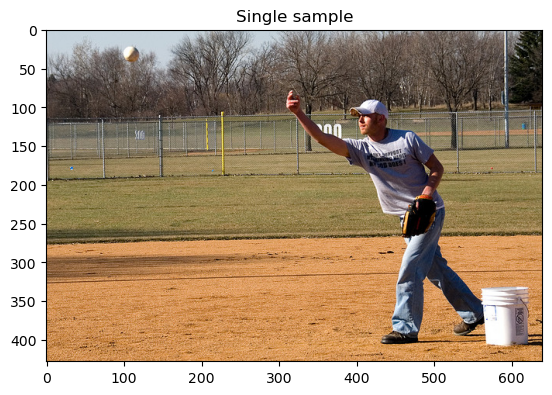

In [29]:
folder = "final_sampled_50"
img = os.listdir(folder)
img = [f for f in img if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

# Load dan tampilkan gambar pertama
img_path = os.path.join(folder, img[41])
image = Image.open(img_path)

plt.imshow(image)
plt.title("Single sample")
plt.show()

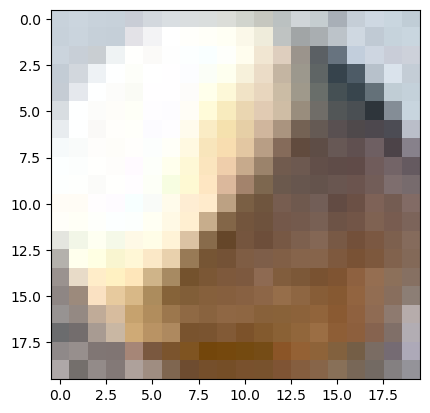

In [71]:
image1 = cv2.imread(os.path.join(folder, img[41]))
x, y, w, h = 100, 22, 20, 20 # Adjust these values as needed
template = image1[y:y+h, x:x+w]
template_rgb = cv2.cvtColor(template, cv2.COLOR_BGR2RGB)

# Display the cropped template
plt.imshow(template_rgb)

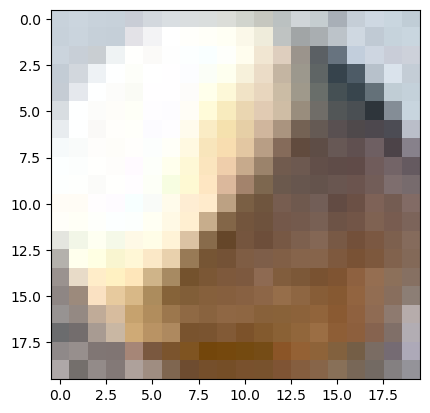

In [72]:
tmp_img = template_rgb
plt.imshow(tmp_img)

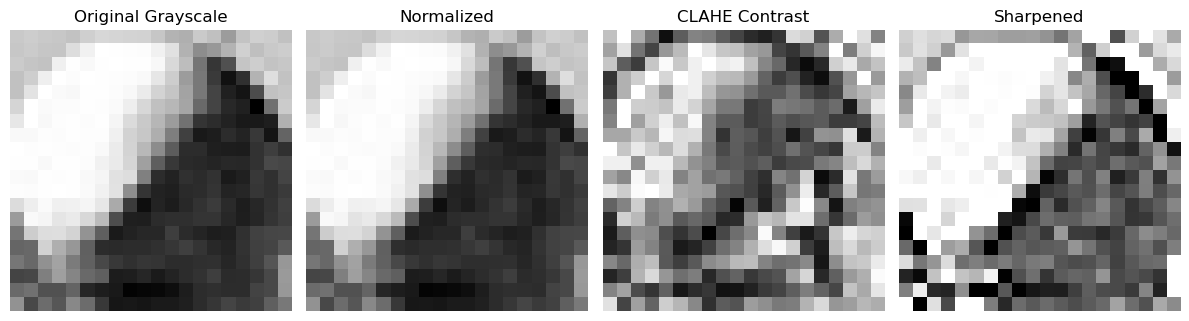

In [73]:
# === Load gambar ===
image_gray = cv2.cvtColor(tmp_img, cv2.COLOR_BGR2GRAY)  # ubah ke grayscale

# === 1. Normalisasi (Min-Max Scaling ke 0–255) ===
normalized = cv2.normalize(image_gray, None, 0, 255, cv2.NORM_MINMAX)

# === 2. Peningkatan Kontras dengan CLAHE ===
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
contrast = clahe.apply(image_gray)

# === 3. Penajaman Citra (Sharpening) ===
# Kernel penajaman
kernel = np.array([[0, -1,  0],
                   [-1, 5, -1],
                   [0, -1,  0]])
sharpened = cv2.filter2D(image_gray, -1, kernel)

# === Tampilkan hasilnya ===
images = [image_gray, normalized, contrast, sharpened]
titles = ["Original Grayscale", "Normalized", "CLAHE Contrast", "Sharpened"]

plt.figure(figsize=(12, 4))
for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')
plt.tight_layout()
plt.show()


In [74]:
tmp_img
print(tmp_img.shape)

(20, 20, 3)


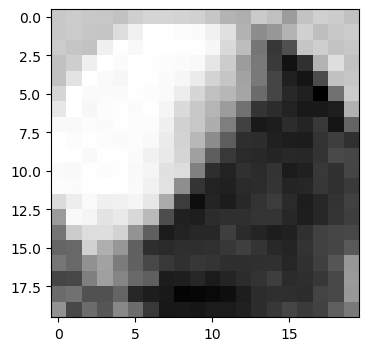

In [75]:
image_gray = cv2.cvtColor(tmp_img, cv2.COLOR_BGR2GRAY)  # ubah ke grayscale

# === 1. Normalisasi (Min-Max Scaling ke 0–255) ===
normalized = cv2.normalize(image_gray, None, 0, 255, cv2.NORM_MINMAX)

plt.figure(figsize=(12, 4))
plt.tight_layout()
plt.imshow(normalized, cmap='gray')
plt.show()


### 2. Teknik CV